# Specifying Libraries and Functions

In [2]:
!pip install mediapipe==0.10.18 opencv-python==4.10.0.84 numpy==1.26.4 matplotlib==3.8.0 sounddevice==0.5.1

In [7]:
import cv2
import numpy as np
import os
import shutil
import time
import mediapipe as mp
from matplotlib import pyplot as plt

# ==========================================
# 1. SETUP AND HELPER FUNCTIONS
# ==========================================

mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

def draw_styled_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2))
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2))
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))

def extract_keypoints(results):
    # Slice [0:23] to keep only Face and Upper Body (excluding hips/legs)
    # Or specific indices if you want to be more precise
    if results.pose_landmarks:
        # Taking the first 25 landmarks (0-24) covers face + upper body up to hips
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark[:25]]).flatten()
    else:
        # 25 landmarks * 4 coordinates
        pose = np.zeros(25*4) 
        
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    
    return np.concatenate([pose, lh, rh])

W0000 00:00:1767769588.496651     264 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769588.526127     264 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769588.528745     265 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769588.529540     263 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769588.529780     264 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769588.538781     263 inference_feedback_manager.cc:114] Feedback manager 

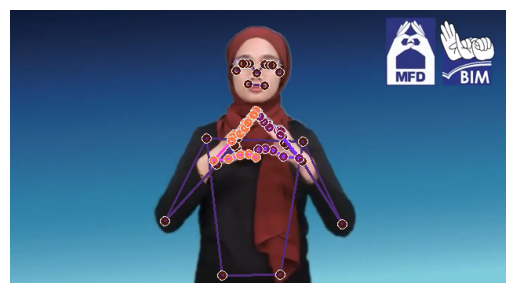

In [8]:
def cv2_imshow(image):
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    if len(image.shape) == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap='gray')
    plt.axis('off') # Hide the x/y axis numbers
    plt.show()
    
def detect_hand_landmarks(image_path):
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        # Load the image using OpenCV
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Make detections
        image, results = mediapipe_detection(image, holistic)

        # Draw landmarks to the frame
        draw_styled_landmarks(image,results)

        # Convert the image back to BGR for OpenCV
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Display the image with hand landmarks
        cv2_imshow(image)


# Testing mediapipe
# Path to your own image file
image_path = '/kaggle/input/cv-frame/test.jpg'

# Call the function to detect hand landmarks
detect_hand_landmarks(image_path)


In [11]:
video_directory = r'//kaggle/input/sign-language-dataset/BIM Dataset V3'
train_dataset_path = '/kaggle/working/video_dataset'

MIN_SAMPLES = 50  # Gestures with fewer than 20 videos will be DROPPED
VALID_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv')

# ==========================================
# 2. PRE-SCAN & DROPPING LOGIC
# ==========================================
print("--- Initial Class Distribution Check ---")
all_gesture_folders = sorted([d for d in os.listdir(video_directory) 
                              if os.path.isdir(os.path.join(video_directory, d))])

valid_gestures = []
dropped_gestures = []

for ges in all_gesture_folders:
    path = os.path.join(video_directory, ges)
    # Only count actual video files
    video_files = [f for f in os.listdir(path) if f.lower().endswith(VALID_EXTENSIONS)]
    
    if len(video_files) >= MIN_SAMPLES:
        valid_gestures.append((ges, video_files))
    else:
        dropped_gestures.append(f"{ges} ({len(video_files)} samples)")

# 1. Total Original Gestures
print(f"Total Original Folders Found: {len(all_gesture_folders)}")
print(f"Original Gestures List:\n{all_gesture_folders}")
print("-" * 30)

# 2. Dropped Gestures Detail
print(f"DROPPED: {len(dropped_gestures)} gestures (SAMPLES < {MIN_SAMPLES})")
if dropped_gestures:
    for d in dropped_gestures:
        print(f"  {d}")
else:
    print("  (None)")
print("-" * 30)

# 3. Final Selection
# Extract just the names from our valid_gestures list of tuples
final_gesture_names = [g[0] for g in valid_gestures]

print(f"FINAL TOTAL: {len(final_gesture_names)} gestures kept.")
print(f"Final Gestures List:\n{final_gesture_names}")
print("="*50 + "\n")

--- Initial Class Distribution Check ---
Total Original Folders Found: 89
Original Gestures List:
['abang', 'ada', 'ambil', 'anak_lelaki', 'anak_perempuan', 'apa', 'apa_khabar', 'arah', 'assalamualaikum', 'ayah', 'baca', 'bagaimana', 'bahasa_isyarat', 'baik', 'bapa_saudara', 'bas', 'bawa', 'beli', 'beli_2', 'berapa', 'berjalan', 'berlari', 'bila', 'bola', 'boleh', 'bomba', 'buang', 'buat', 'curi', 'dapat', 'dari', 'emak', 'emak_saudara', 'hari', 'hi', 'hujan', 'jahat', 'jam', 'jangan', 'jumpa', 'kacau', 'kakak', 'keluarga', 'kereta', 'kesakitan', 'lelaki', 'lemak', 'lupa', 'main', 'makan', 'mana', 'marah', 'mari', 'masa', 'masalah', 'minum', 'mohon', 'nasi', 'nasi_lemak', 'panas', 'panas_2', 'pandai', 'pandai_2', 'payung', 'pen', 'pensil', 'perempuan', 'pergi', 'pergi_2', 'perlahan', 'perlahan_2', 'pinjam', 'polis', 'pukul', 'ribut', 'sampai', 'saudara', 'sejuk', 'sekolah', 'siapa', 'sudah', 'suka', 'tandas', 'tanya', 'teh_tarik', 'teksi', 'tidur', 'tolong', 'tolong_2']
---------------

In [12]:
# ==========================================
# 3. DATA ACQUISITION LOOP
# ==========================================

# Clean start
if os.path.exists(train_dataset_path):
    shutil.rmtree(train_dataset_path)
os.makedirs(train_dataset_path, exist_ok=True)

with mp.solutions.holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    for i, (ges, video_files) in enumerate(valid_gestures):
        gesture_save_path = os.path.join(train_dataset_path, ges)
        os.makedirs(gesture_save_path, exist_ok=True)
        
        total_videos = len(video_files)
        print(f"[{i+1}/{len(valid_gestures)}] Extracting: '{ges}'...")
        
        for j, vid in enumerate(video_files):
            print(f"    > Video {j+1}/{total_videos}: {vid[:25]}...", end='\r')
            
            video_path = os.path.join(video_directory, ges, vid)
            cap = cv2.VideoCapture(video_path)
            
            # Read Frames
            frames = []
            while True:
                ret, frame = cap.read()
                if not ret: break
                frames.append(frame)
            cap.release()
            
            # Internal Validation: Skip if video is empty/corrupt
            if len(frames) == 0:
                continue

            # Uniform Sampling (30 frames)
            frame_indices = np.linspace(0, len(frames) - 1, 30).astype(int)
            sequence_data = []
            
            for idx in frame_indices:
                _, results = mediapipe_detection(frames[idx], holistic)
                keypoints = extract_keypoints(results) 
                sequence_data.append(keypoints)
            
            # Save .npy
            save_name = os.path.splitext(vid)[0] + '.npy'
            np.save(os.path.join(gesture_save_path, save_name), np.array(sequence_data))
        
        print(f"\n    Completed '{ges}'.")

print("\nLandmarks Dataset Creation Complete.")

[1/52] Extracting: 'abang'...


W0000 00:00:1767769729.263732     456 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769729.323149     456 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769729.327535     454 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769729.331007     457 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769729.335693     456 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767769729.348547     457 inference_feedback_manager.cc:114] Feedback manager 

    > Video 72/72: abang_1_4_2.mp4...
    Completed 'abang'.
[2/52] Extracting: 'anak_lelaki'...


[mov,mp4,m4a,3gp,3g2,mj2 @ 0xdf39000] moov atom not found


    > Video 90/90: anaklelaki_3_4_2.mp4...4...
    Completed 'anak_lelaki'.
[3/52] Extracting: 'anak_perempuan'...
    > Video 90/90: anak_perempuan_4_4_2.mp4....
    Completed 'anak_perempuan'.
[4/52] Extracting: 'apa'...
    > Video 72/72: apa_3_3_3.mp4...
    Completed 'apa'.
[5/52] Extracting: 'apa_khabar'...
    > Video 102/102: apakhabar_02_04_01.mp4....
    Completed 'apa_khabar'.
[6/52] Extracting: 'assalamualaikum'...
    > Video 90/90: assalamualaikum_4_4_3.mp4...
    Completed 'assalamualaikum'.
[7/52] Extracting: 'ayah'...
    > Video 89/89: bapa_4_1_3.mp4......
    Completed 'ayah'.
[8/52] Extracting: 'bagaimana'...
    > Video 72/72: bagaimana_1_2_3.mp4...
    Completed 'bagaimana'.
[9/52] Extracting: 'bahasa_isyarat'...
    > Video 54/54: bahasa_isyarat_2_2_2.mp4...
    Completed 'bahasa_isyarat'.
[10/52] Extracting: 'baik'...
    > Video 177/177: baik_2_4_2.mp4...2.mp4...
    Completed 'baik'.
[11/52] Extracting: 'bapa_saudara'...
    > Video 90/90: bapa saudara_01_05_0

In [13]:
import shutil
import os

# Define the source folder and the output zip name
source_folder = '/kaggle/working/video_dataset'
output_filename = '/kaggle/working/dataset' # Do not add .zip here, shutil does it automatically

print("Zipping files... this may take a moment.")
shutil.make_archive(output_filename, 'zip', source_folder)
print(f"Success! Created {output_filename}.zip")

Zipping files... this may take a moment.
Success! Created /kaggle/working/dataset.zip
